In [65]:
import pandas
import matplotlib.pyplot
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Carregar os dados
dataframe = pandas.read_csv("01 - Dados - Clustering.csv")
# Exibir as 5 primeiras linhas
print(dataframe.head())
# Quantidade total de registros
print("Total de registros:", len(dataframe))

   id  horas_semana  dias_acesso_mes
0   1             2                5
1   2             3                6
2   3             1                4
3   4             4                7
4   5             2                6
Total de registros: 40


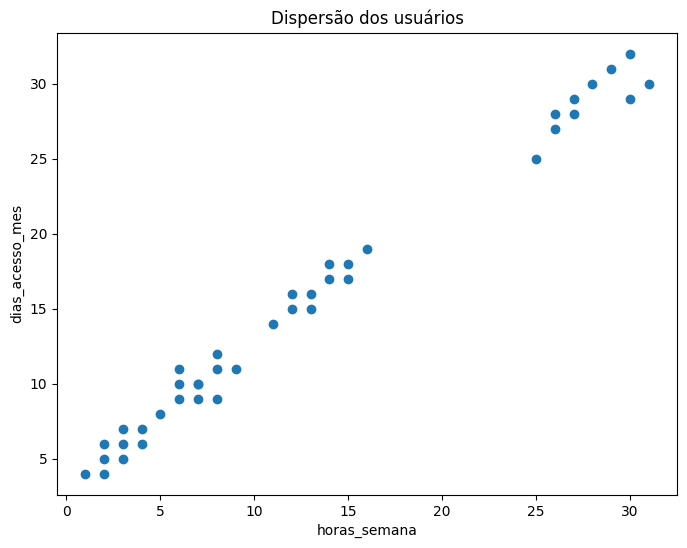

In [66]:
# Parte 2
matplotlib.pyplot.figure(figsize=(8, 6))

matplotlib.pyplot.scatter(
    dataframe["horas_semana"],
    dataframe["dias_acesso_mes"]
)

matplotlib.pyplot.xlabel("horas_semana")
matplotlib.pyplot.ylabel("dias_acesso_mes")
matplotlib.pyplot.title("Dispersão dos usuários")

matplotlib.pyplot.show()

In [67]:
# parte 3
algoritmo_kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

X_kmeans = dataframe[["horas_semana", "dias_acesso_mes"]]

algoritmo_kmeans.fit(X_kmeans)

dataframe["grupo"] = algoritmo_kmeans.labels_

print(dataframe.head())

   id  horas_semana  dias_acesso_mes  grupo
0   1             2                5      2
1   2             3                6      2
2   3             1                4      2
3   4             4                7      2
4   5             2                6      2


In [ ]:
# parte 4
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

score_silhouette = silhouette_score(X_kmeans, algoritmo_kmeans.labels_) # maior melhor (separador)
print("Silhouette score:", score_silhouette)

score_calinski = calinski_harabasz_score(X_kmeans, algoritmo_kmeans.labels_) # maior melhor (separador)
print("Calinski-Harabasz score:", score_calinski)

score_davies = davies_bouldin_score(X_kmeans, algoritmo_kmeans.labels_) # menor melhor (ajuntador)
print("Davies-Bouldin score:", score_davies)

Silhouette score: 0.6947582909201341
Calinski-Harabasz score: 480.40459197414486
Davies-Bouldin score: 0.3602417385448739


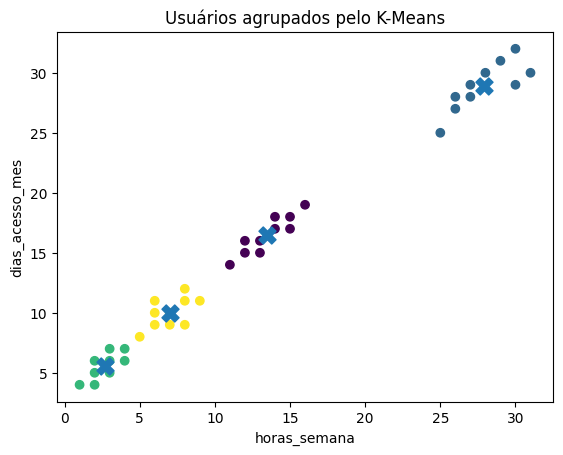

In [69]:
matplotlib.pyplot.scatter(
    dataframe["horas_semana"],
    dataframe["dias_acesso_mes"],
    c=dataframe["grupo"]
)

matplotlib.pyplot.scatter(
    algoritmo_kmeans.cluster_centers_[:, 0], # Todas as linhas coluna 0, Atributo 1
    algoritmo_kmeans.cluster_centers_[:, 1], # Todas as linhas coluna 1, Atributo 2
    marker="X",
    s=150
)

matplotlib.pyplot.xlabel("horas_semana")
matplotlib.pyplot.ylabel("dias_acesso_mes")
matplotlib.pyplot.title("Usuários agrupados pelo K-Means")

matplotlib.pyplot.show()

Exercício 2: 
atributos: idade, paginas_visitadas, tempo_site, produtos_visualizados, carrinho 
(0 = vazio, 1 = com itens), compra (0 = não concluiu, 1 = concluiu). 
Dataset-DT-novo

In [70]:
import pandas
from sklearn.model_selection import train_test_split
# Carregar os dados
dataframe = pandas.read_csv("02 - Dados - Decision Tree.csv")
# Exibir as 5 primeiras linhas
print(dataframe.head())
# Quantidade total de registros
print("Total de registros:", len(dataframe))
print("Total de atributos:", len(dataframe.columns))

   idade  paginas_visitadas  tempo_site  produtos_visualizados  carrinho  \
0     18                  2           1                      1         0   
1     19                  3           2                      2         0   
2     20                  4           2                      2         0   
3     21                  5           3                      3         0   
4     22                  4           3                      2         0   

   compra  
0       0  
1       0  
2       0  
3       0  
4       0  
Total de registros: 87
Total de atributos: 6


In [71]:
# Variáveis de entrada (X)
X = dataframe[
    [
        "idade",
        "paginas_visitadas",
        "tempo_site",
        "produtos_visualizados",
        "carrinho"
    ]
]

# Variável alvo (y)
y = dataframe["compra"]

# Divisão treino/teste
# retorno vem em ordem que enviamos os dataframes, se enviassemos y primeiro, primeiro viria y no retorno
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split( 
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Registros de treinamento:", len(X_treinamento))
print("Registros de teste:", len(X_teste))

Registros de treinamento: 60
Registros de teste: 27


In [72]:
from sklearn.tree import DecisionTreeClassifier

# Criar o modelo
modelo_arvore = DecisionTreeClassifier(random_state=42)

# Treinar o modelo
modelo_arvore.fit(X_treinamento, y_treinamento)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [73]:
# Previsões no conjunto de teste
previsoes = modelo_arvore.predict(X_teste)

resultado = pandas.DataFrame({
    "real": y_teste.values,
    "previsto": previsoes
})

print(resultado.head(10))

   real  previsto
0     0         0
1     0         0
2     1         1
3     1         1
4     1         1
5     0         0
6     0         0
7     1         1
8     0         0
9     0         0


In [74]:
from sklearn.metrics import accuracy_score
acuracia = accuracy_score(y_teste, previsoes)
print("Acurácia:", acuracia)

from sklearn.metrics import confusion_matrix
matriz_confusao = confusion_matrix(y_teste, previsoes)
print("Matriz de confusão:\n", matriz_confusao)

from sklearn.metrics import recall_score
recall = recall_score(y_teste, previsoes)
print("Recall:", recall)

from sklearn.metrics import f1_score
f1 = f1_score(y_teste, previsoes)
print("F1 score:", f1)

from sklearn.metrics import classification_report
relatorio = classification_report(y_teste, previsoes)
print(relatorio)

Acurácia: 1.0
Matriz de confusão:
 [[15  0]
 [ 0 12]]
Recall: 1.0
F1 score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        12

    accuracy                           1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27



In [75]:
novos_dados = pandas.DataFrame([
    {
        "idade": 31,
        "paginas_visitadas": 12,
        "tempo_site": 10,
        "produtos_visualizados": 8,
        "carrinho": 1
    },
    {
        "idade": 24,
        "paginas_visitadas": 5,
        "tempo_site": 4,
        "produtos_visualizados": 3,
        "carrinho": 0
    }
])

previsoes_novas = modelo_arvore.predict(novos_dados)
print(previsoes_novas)

[1 0]


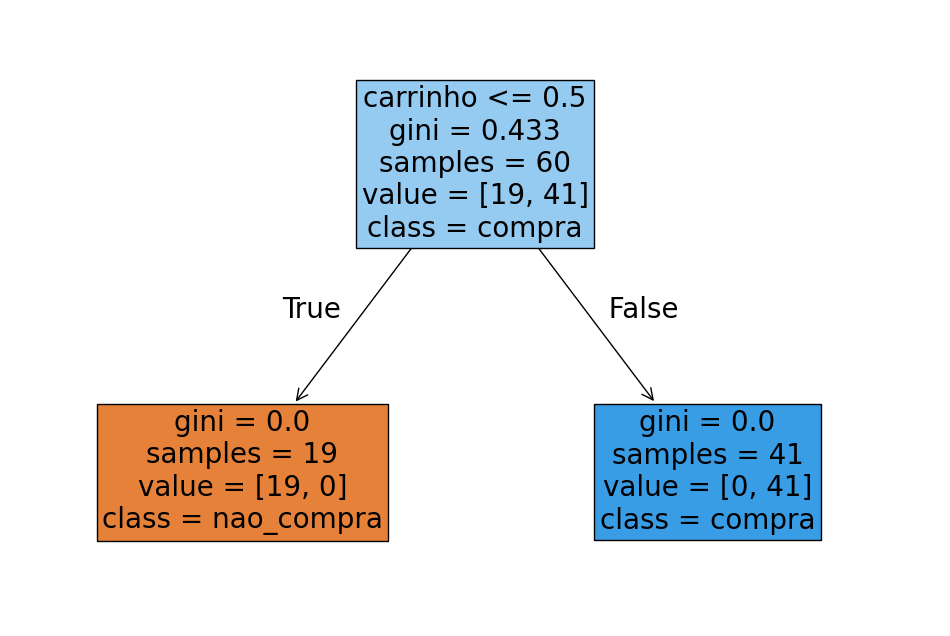

In [76]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plot_tree(
    modelo_arvore,
    feature_names=["idade","paginas_visitadas","tempo_site","produtos_visualizados","carrinho"],
    class_names=["nao_compra","compra"],
    filled=True,
    fontsize=20
)

plt.show()